# 04 — Model Evaluation & Business Insights


This notebook answers the two most important questions of the entire project:

1. **Which model performs best and does complexity justify the trade-off?**
2. **How do we translate model output into real business decisions?**


---

## Evaluation Philosophy

We do **not** optimize for accuracy. In a churn problem:

| Mistake | Business Cost |
|---|---|
| False Negative (missed churner) | Lost customer — high cost |
| False Positive (wrong alert) | Wasted retention offer — low cost |

Therefore our primary metrics are **ROC-AUC** (overall ranking ability) and **Recall** (catching actual churners).

---

## 1. Imports and Data Loading

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt

from modeling import split_data
from evaluation import (
    load_all_models,
    build_metrics_table,
    plot_all_roc_curves,
    plot_metrics_comparison,
    build_risk_table,
    plot_risk_tier_summary,
    top_risk_customers,
)

df = pd.read_csv('../data/featured_churn.csv')
print('Loaded featured data. Shape:', df.shape)

Loaded featured data. Shape: (7032, 32)


---
## 2. Reproduce Train/Test Split

We use the exact same split parameters (random_state=42, stratified) as in modeling notebooks to ensure evaluation is on identical test data.

In [2]:
X_train, X_test, y_train, y_test = split_data(df)

print(f'Test set: {X_test.shape[0]} rows  |  Churn rate: {y_test.mean()*100:.1f}%')

Test set: 1407 rows  |  Churn rate: 26.6%


---
## 3. Load All Saved Models

In [4]:
models = load_all_models(folder='../models')
print('\nAll models loaded successfully.')

Loaded: Logistic Regression
Loaded: Random Forest
Loaded: Gradient Boosting

All models loaded successfully.


---
## 4. Side-by-Side Metrics Comparison

The table below answers: *does increased complexity materially improve decision quality?*

In [5]:
metrics_df = build_metrics_table(models, X_test, y_test)

print('\nFull Metrics Comparison:')
print(metrics_df.to_string(index=False))


Full Metrics Comparison:
              Model  ROC-AUC  Recall  Precision     F1  Accuracy
  Gradient Boosting   0.8404  0.7968     0.5017 0.6157    0.7356
Logistic Regression   0.8353  0.7941     0.4901 0.6061    0.7257
      Random Forest   0.8134  0.4813     0.6207 0.5422    0.7839


---
## 5. Metrics Bar Chart

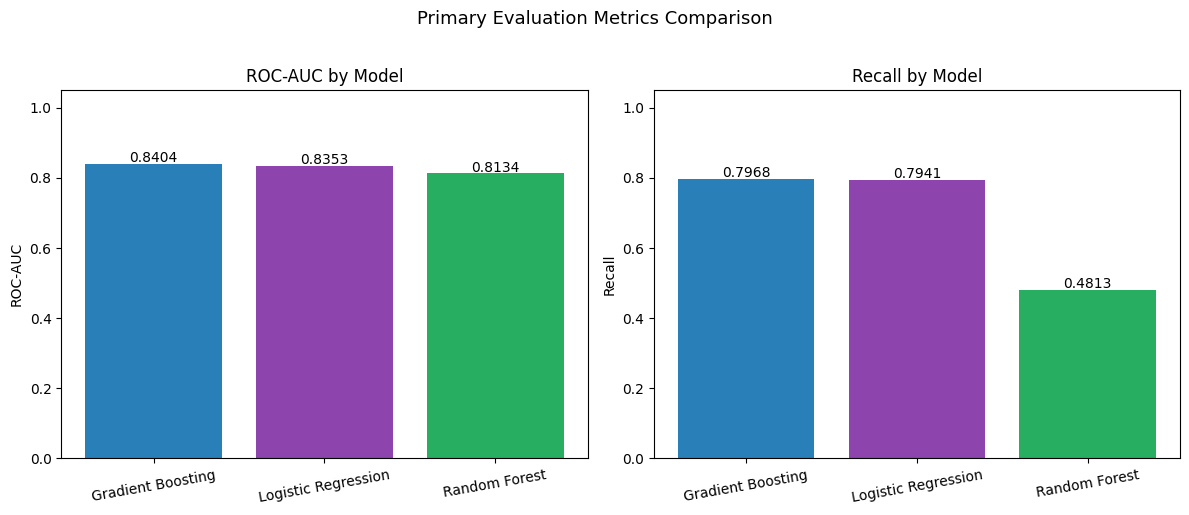

In [6]:
plot_metrics_comparison(metrics_df)

---
## 6. ROC Curve — All Models Overlaid

Overlaying all three ROC curves on a single chart gives the clearest visual answer to model comparison.

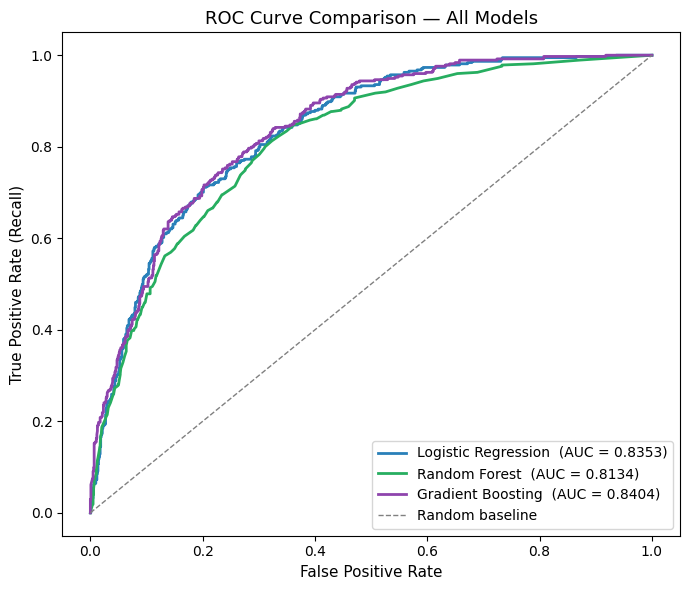

In [7]:
plot_all_roc_curves(models, X_test, y_test)

---
## 7. Model Selection Justification

Based on the results above, we can now make an evidence-based model selection decision.

In [8]:
lr_auc    = metrics_df.loc[metrics_df['Model'] == 'Logistic Regression', 'ROC-AUC'].values[0]
best_auc  = metrics_df['ROC-AUC'].max()
best_model_name = metrics_df.loc[metrics_df['ROC-AUC'].idxmax(), 'Model']
auc_gap   = round(best_auc - lr_auc, 4)

lr_recall   = metrics_df.loc[metrics_df['Model'] == 'Logistic Regression', 'Recall'].values[0]
best_recall = metrics_df['Recall'].max()
recall_gap  = round(best_recall - lr_recall, 4)

print('=' * 55)
print('  MODEL SELECTION JUSTIFICATION')
print('=' * 55)
print(f'  Best ROC-AUC model : {best_model_name} ({best_auc})')
print(f'  Logistic Regression: AUC = {lr_auc}  |  Recall = {lr_recall}')
print(f'  AUC gap over LR    : {auc_gap}')
print(f'  Recall gap over LR : {recall_gap}')
print()
if auc_gap < 0.01 and recall_gap < 0.01:
    print('  CONCLUSION: The performance gap is marginal (<0.01).')
    print('  Logistic Regression is JUSTIFIED as primary model.')
    print('  Interpretability and transparency outweigh minimal gains.')
else:
    print(f'  CONCLUSION: {best_model_name} shows meaningful improvement.')
    print('  Consider using it if interpretability is not a hard requirement.')
print('=' * 55)

  MODEL SELECTION JUSTIFICATION
  Best ROC-AUC model : Gradient Boosting (0.8404)
  Logistic Regression: AUC = 0.8353  |  Recall = 0.7941
  AUC gap over LR    : 0.0051
  Recall gap over LR : 0.0027

  CONCLUSION: The performance gap is marginal (<0.01).
  Logistic Regression is JUSTIFIED as primary model.
  Interpretability and transparency outweigh minimal gains.


---
## 8. From Model Output to Business Action

A model that produces probabilities is only valuable if those probabilities drive decisions.

Here we use **Logistic Regression** (primary model) to score every test customer by churn risk and assign them to tiers:

| Risk Tier | Probability | Action |
|---|---|---|
| High | > 0.70 | Priority retention offer — immediate outreach |
| Medium | 0.40 – 0.70 | Soft engagement — loyalty rewards |
| Low | < 0.40 | No action needed — monitor only |

In [9]:
lr_model = models['Logistic Regression']
risk_df = build_risk_table(lr_model, X_test, y_test, model_name='Logistic Regression')

print('Risk table sample (top 10 highest-risk customers):')
print(risk_df.head(10).to_string(index=False))

Risk table sample (top 10 highest-risk customers):
 Churn_Probability  Actual_Churn Risk_Tier
          0.934127             0      High
          0.933672             1      High
          0.923958             1      High
          0.922197             1      High
          0.918365             1      High
          0.918228             1      High
          0.917473             1      High
          0.916854             1      High
          0.909547             1      High
          0.907804             0      High


---
## 9. Risk Tier Summary

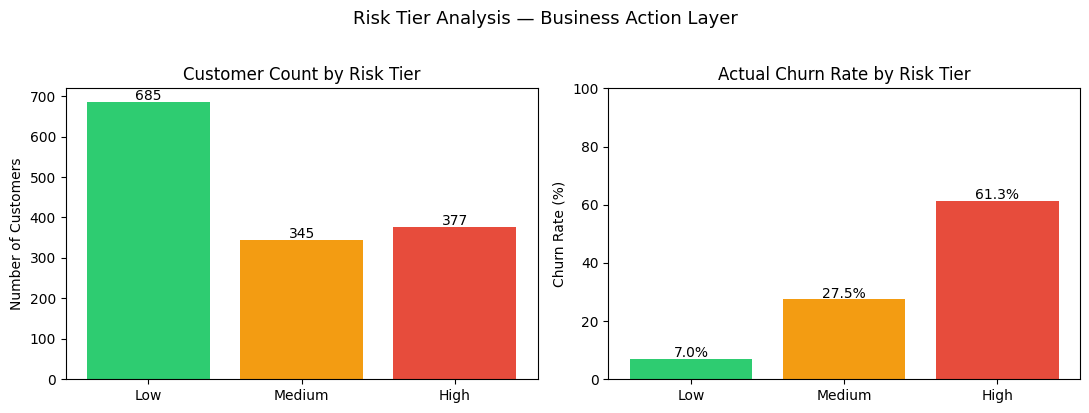


Risk Tier Summary:
Risk_Tier  Customers  Actual_Churn_Rate
      Low        685                7.0
   Medium        345               27.5
     High        377               61.3


In [10]:
tier_summary = plot_risk_tier_summary(risk_df)

---
## 10. Top 20% High-Risk Customers

Rather than targeting all customers with retention offers (costly and inefficient), the model enables **precision targeting**.

Focusing on the top 20% highest-risk customers concentrates retention spend where it matters most.

* Top 20% highest-risk customers: 281 customers
* Actual churn rate in this group: 66.2%
vs. overall churn rate: 26.6%

* By targeting only the top 20% of customers,
the business can reach a disproportionate share of actual churners
while significantly reducing retention campaign costs.

---
## 11. Limitations & Future Work


LIMITATIONS
=======================================================

  Correlation ≠ Causation:
  Statistical associations between contract type, payment method, and churn do not prove these features directly cause churn. Confounding variables may exist.

  Dataset Limitations:
  The dataset lacks pricing history, customer service interaction logs, and service quality metrics — all of which likely influence churn.

  Behavioral Proxies:
  Payment method is used as a proxy for behavioral lock-in. It is an indirect signal, not a direct measure of customer satisfaction.

  Static Snapshot:
  The model is trained on a single point-in-time snapshot. It does not capture how customer behavior changes over time.


FUTURE WORK
=======================================================
  * Survival analysis — model time-to-churn, not just binary outcome
  * Cost-sensitive learning — incorporate actual retention cost vs. customer lifetime value
  * Time-series modeling — capture behavioral drift over customer tenure
  * Threshold optimization — tune decision threshold based on business cost matrix

---
## 12. Final Project Statement

> *This project uses hypothesis-driven analysis to identify churn-related behaviors and predictive modeling to translate those insights into individual-level risk scores, enabling targeted and cost-effective churn prevention strategies.*

---

## What This Project Demonstrates

| Skill | Evidence |
|---|---|
| Structured thinking | Hypotheses formed before any modeling |
| Research discipline | EDA and modeling kept deliberately separate |
| Responsible ML | Model justified by interpretability, not just performance |
| Business translation | Risk tiers and top-20% targeting strategy |
| Academic honesty | Limitations and future work explicitly stated |
| End-to-end execution | Raw data → preprocessing → EDA → features → modeling → evaluation |